Training notebook
==================

In this training notebook, we will demonstrate the basic usage of sequencing, both using simple predefined waveforms and using Q1ASM to set the desired signals in the sequencer. The readout modules are able to acquire data in order to inspect and process raw input data and this notebook will showcase the basics of acquisitions.


Setup
-----

First, we are going to import the required packages.

In [1]:
import json
import math
import pprint as pprint


import matplotlib.pyplot as plt
import numpy as np


import scipy.signal

from qblox_instruments import Cluster, PlugAndPlay

### Scan For Clusters

We scan for the available devices connected via ethernet using the Plug & Play functionality of the Qblox Instruments package (see [Plug & Play](https://qblox-qblox-instruments.readthedocs-hosted.com/en/master/api_reference/tools.html#api-pnp) for more info).

In [4]:
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.9.1 with name "cluster-mm" and serial number 00015_2251_003


In [3]:
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"

### Connect to Cluster

We now make a connection with the Cluster.

In [5]:
try:  # Close the chosen QCodes instrument to prevent name clash
    Cluster.find_instrument(cluster_name).close()
except KeyError:
    pass

cluster = Cluster(
    name=cluster_name,
    identifier=cluster_ip,
)

In [7]:
cluster.IDN()

{'manufacturer': 'qblox',
 'model': 'cluster_mm',
 'serial_number': '00015_2251_003',
 'firmware': {'fpga': {'version': '0.9.0',
   'build': '30/07/2024-12:43:40',
   'hash': '80063cc5',
   'dirty': False},
  'kernel_mod': {'version': '0.9.1',
   'build': '12/09/2024-14:05:21',
   'hash': '642f5389',
   'dirty': False},
  'application': {'version': '0.9.1',
   'build': '12/09/2024-14:05:21',
   'hash': '642f5389',
   'dirty': False},
  'driver': {'version': '0.14.1',
   'build': '06/09/2024-07:57:25',
   'hash': '0879e84f',
   'dirty': False}}}

#### Get connected modules

In [8]:
def get_connected_modules(cluster, filter_fn=None):
    def checked_filter_fn(mod):
        if filter_fn is not None:
            return filter_fn(mod)
        return True

    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }

In [9]:
# QCM baseband modules
control_modules = get_connected_modules(cluster, lambda mod: mod.is_qcm_type and not mod.is_rf_type)
control_modules

{2: <Module: cluster0_module2 of Cluster: cluster0>}

In [10]:
# QCM baseband modules
readout_modules = get_connected_modules(cluster, lambda mod: mod.is_qrm_type and not mod.is_rf_type)
readout_modules

{4: <Module: cluster0_module4 of Cluster: cluster0>}

In [11]:
control_module = list(control_modules.values())[0]

readout_module = list(readout_modules.values())[0]

### Reset the Cluster

We reset the Cluster to enter a well-defined state. Note that resetting will clear all stored parameters, so resetting between experiments is usually not desirable.

In [12]:
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, Flags: NONE, Slot flags: NONE


Generate basic waveforms<a id='gen_wf'></a>
------------------------------

We generate basic waveforms by passing data for a typical waveform then assign each waveform a certain index. In Q1ASM, we call on that waveform by inputing the assigned index inside the real time instruction play.

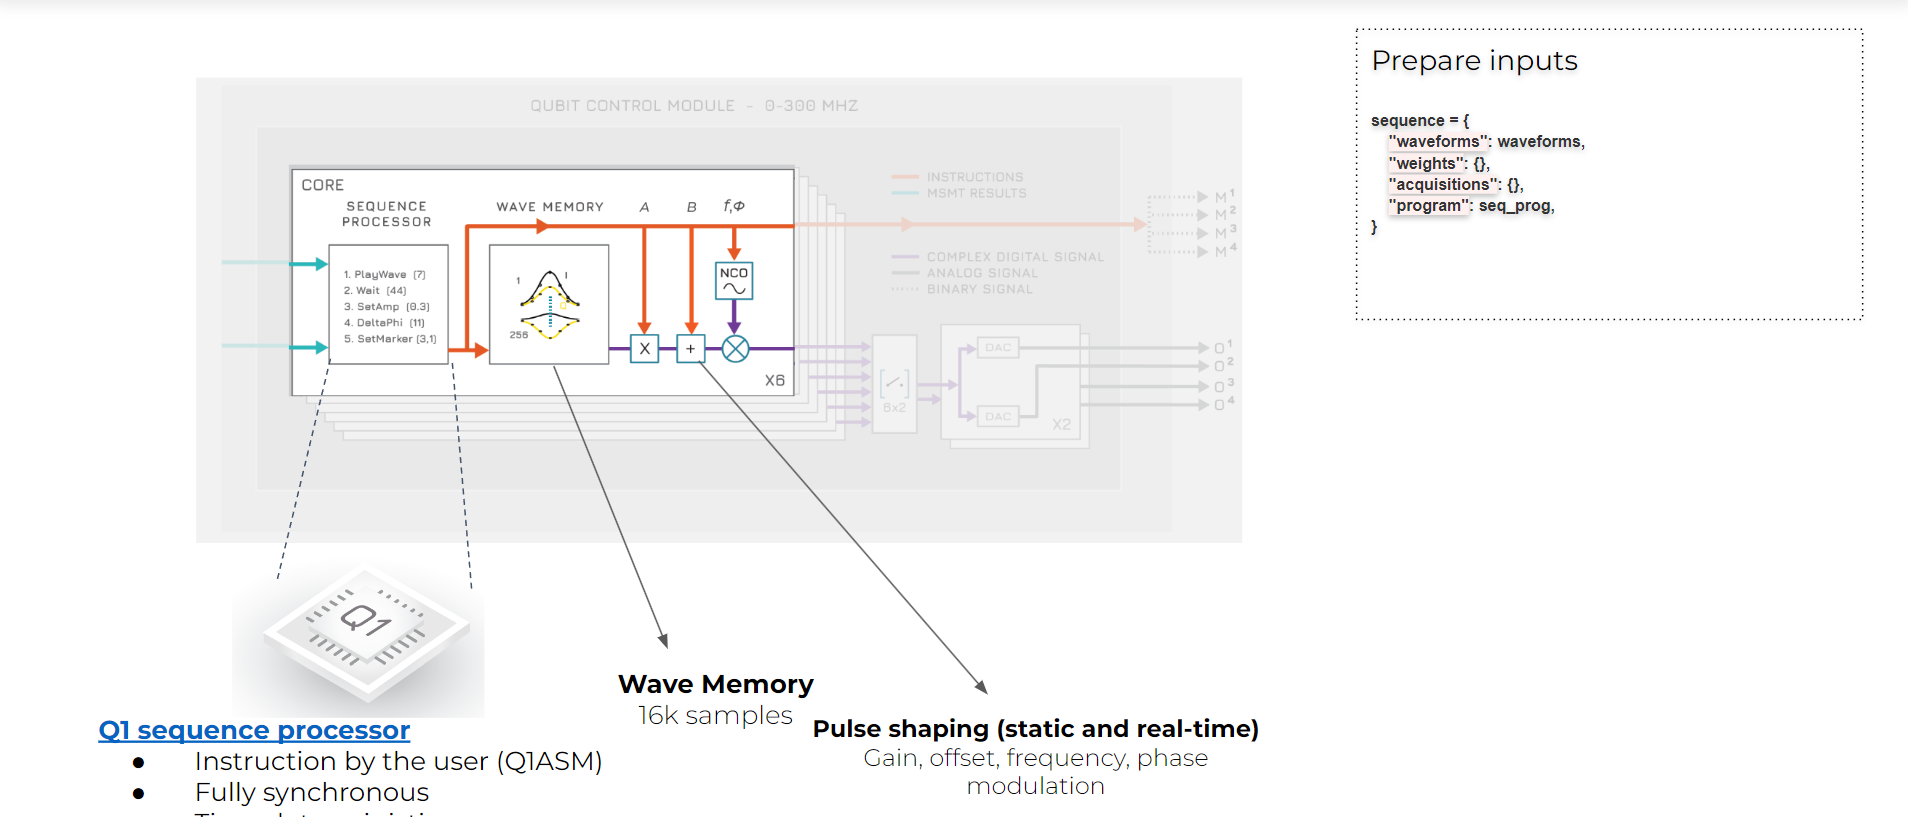

In [13]:

waveform_length = 600 #ns

waveforms = {
    "gaussian": {
        "data": scipy.signal.windows.gaussian(
            waveform_length, std=0.12 * waveform_length
        ).tolist(),
        "index": 0,
    },
    "sine": {
        "data": [
            math.sin((2 * math.pi / waveform_length) * i)
            for i in range(0, waveform_length)
        ],
        "index": 1,
    },
    "block": {"data": [1.0 for _ in range(0, waveform_length)], "index": 2},
}

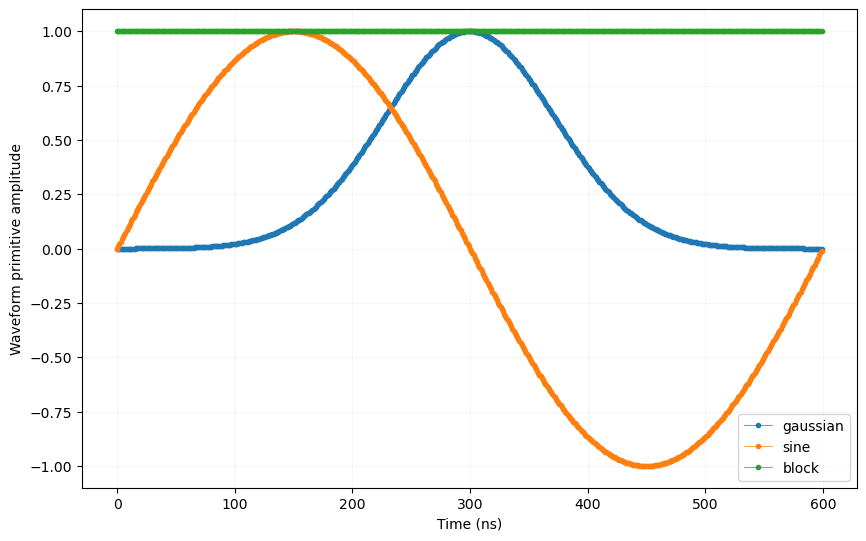

In [14]:
time = np.arange(0, max(map(lambda d: len(d["data"]), waveforms.values())), 1)
fig, ax = plt.subplots(1, 1, figsize=(10, 10 / 1.61))

for wf, d in waveforms.items():
    ax.plot(time[: len(d["data"])], d["data"], ".-", linewidth=0.5, label=wf)

ax.legend(loc=4)
ax.grid(alpha=1 / 10)
ax.set_ylabel("Waveform primitive amplitude")
ax.set_xlabel("Time (ns)")

plt.draw()
plt.show()

In [15]:
# Sequence program for a basic play of waveforms.
basic_seq_prog = """ 
      set_mrk 15  # 1111
      play    0,0,4     #Play the gaussian (index 0) and sine (index 1) waveforms on path 0 resp path 1. Wait 4 ns.
      wait    1000      #Wait 1000ns. 

      stop                #Stop.
"""

In [16]:
# Add sequence program, waveforms, weights and acquisitions to single dictionary and write to JSON file.
sequence = {
    "waveforms": waveforms,
    "weights": {},
    "acquisitions": {},
    "program": basic_seq_prog,
}

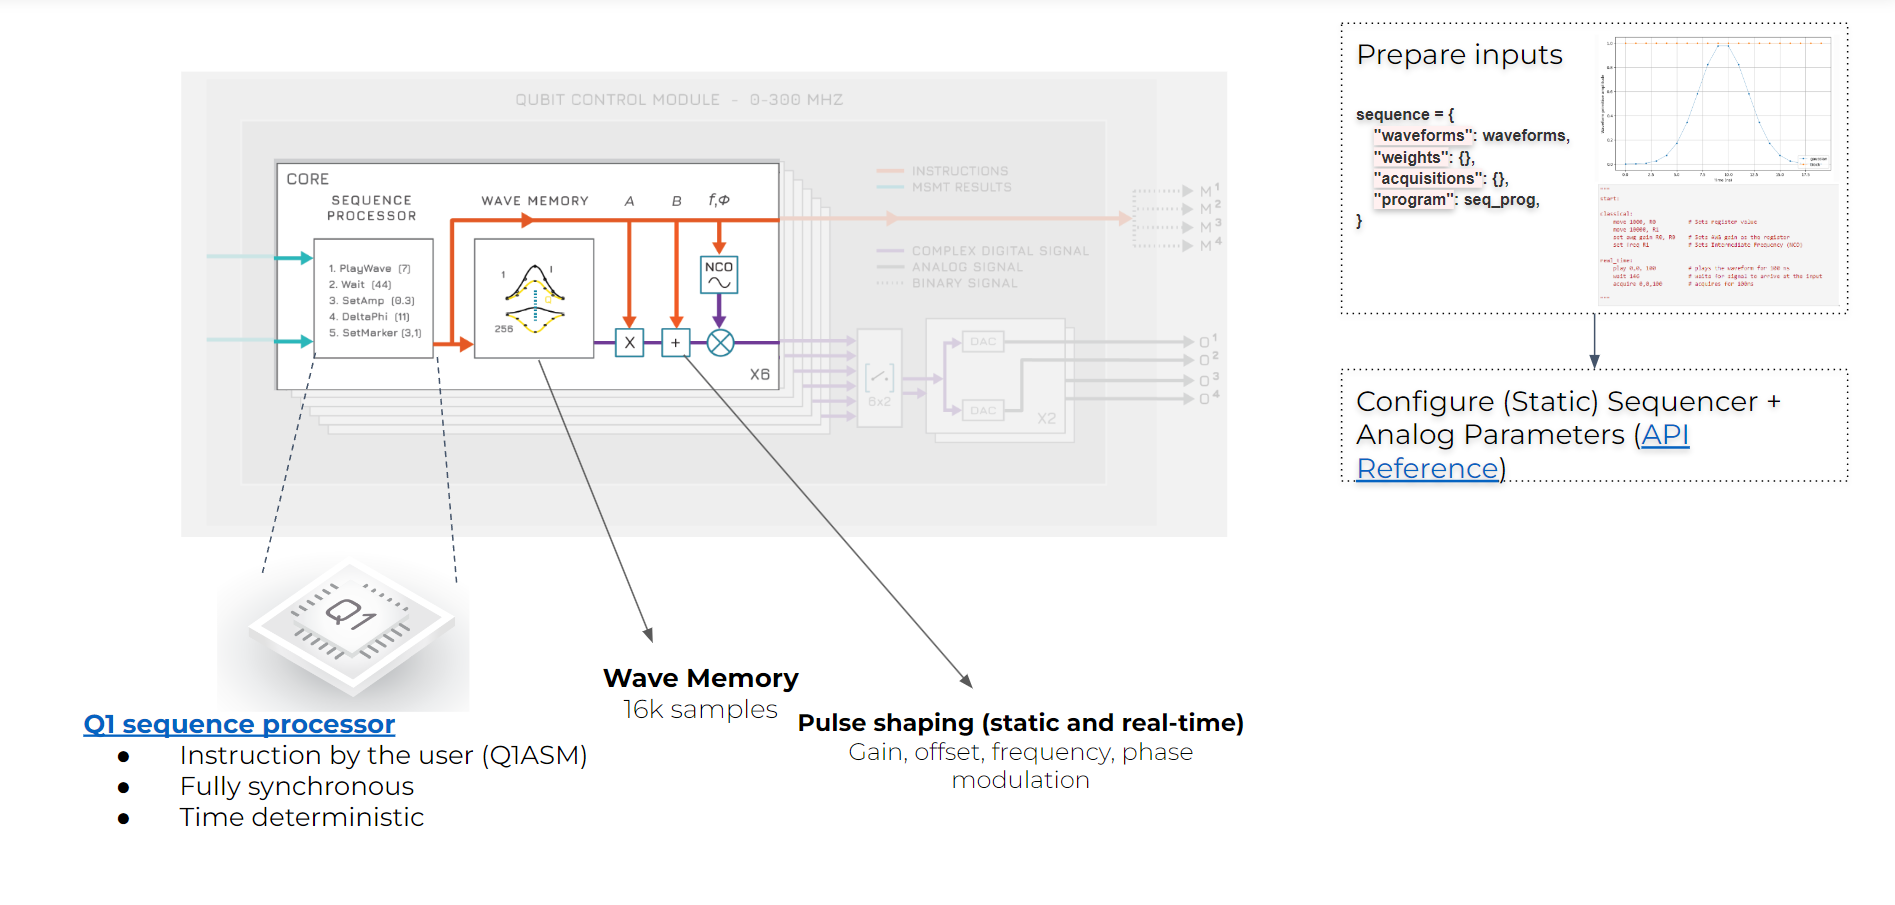

In [17]:
# Wait for the sequencer to stop with a timeout period of one minute.
control_module.sequencer0.sequence(sequence)

# Map the sequencer to a specific output (but first disable all sequencer connections).
control_module.disconnect_outputs()
# Connect 
# control_module.sequencer0.connect_out0("I")
# control_module.sequencer0.connect_out1("Q")
control_module.sequencer0.connect_sequencer("out0_1")

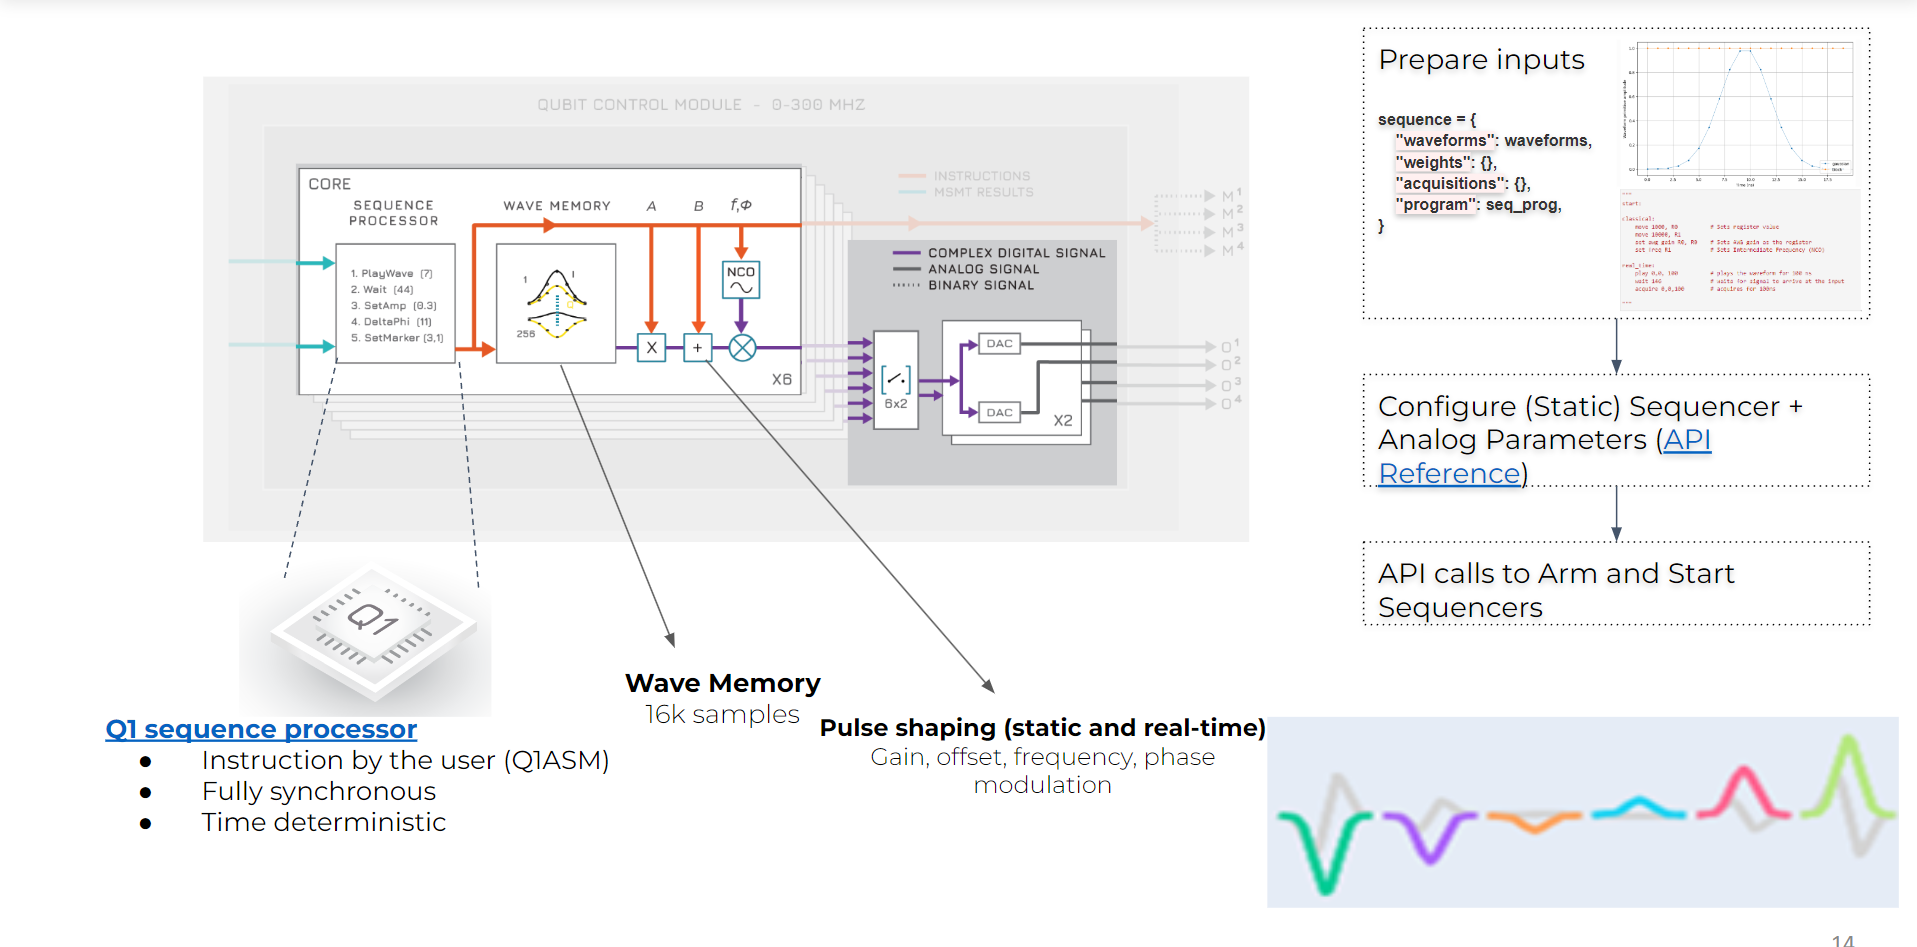

In [18]:
# Arm and start the sequencer.
control_module.arm_sequencer(0)
control_module.start_sequencer()

# Print status of the sequencer.
print(control_module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


Generate waveform with Q1ASM
--------------------
With Q1ASM we can dynamically set parameters of our desired waveform without defining a waveform as done previously. The real time instructions will then be able to execute all the set parameters prior to the real time instruction. The sequence dictionary does then only have to consider the Q1ASM program as input.

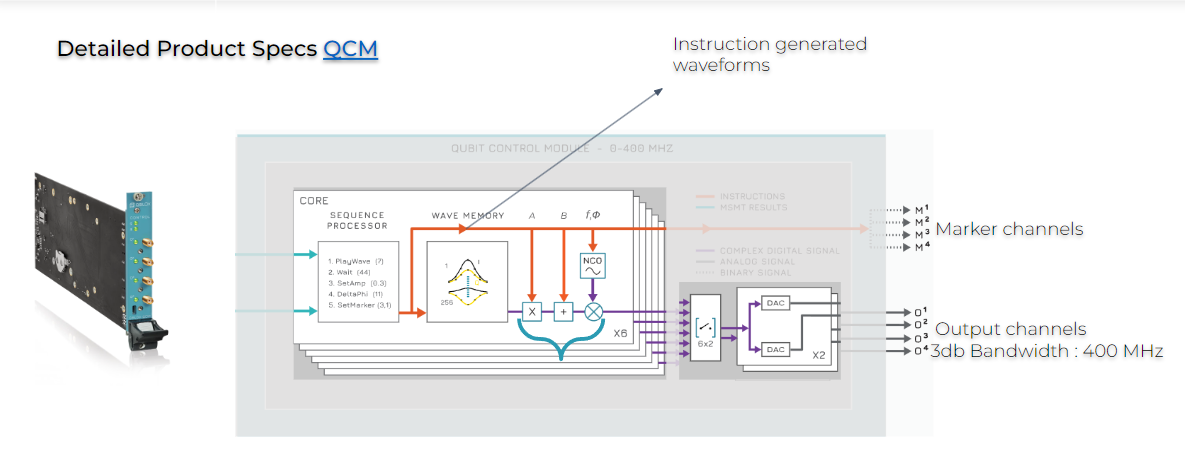

In [19]:
sine_seq_prog = """
       set_mrk 15
       reset_ph
       set_awg_offs 10000,10000   #Feed a waveform with amplitude 0.3.
       upd_param 400              #Update the parameters set and show it on the oscilloscope. 
       stop                       
"""

sequence = {  
    "waveforms": {},  
    "weights": {},
    "acquisitions": {},
    "program": sine_seq_prog,
}
with open("sequence.json", "w", encoding="utf-8") as file:
    json.dump(sequence, file, indent=4)
    file.close()

One may set the statical parameters of the module to complement the parameters set dynamically in the Q1ASM but for the sake of simplicity we set the offset to 0. 

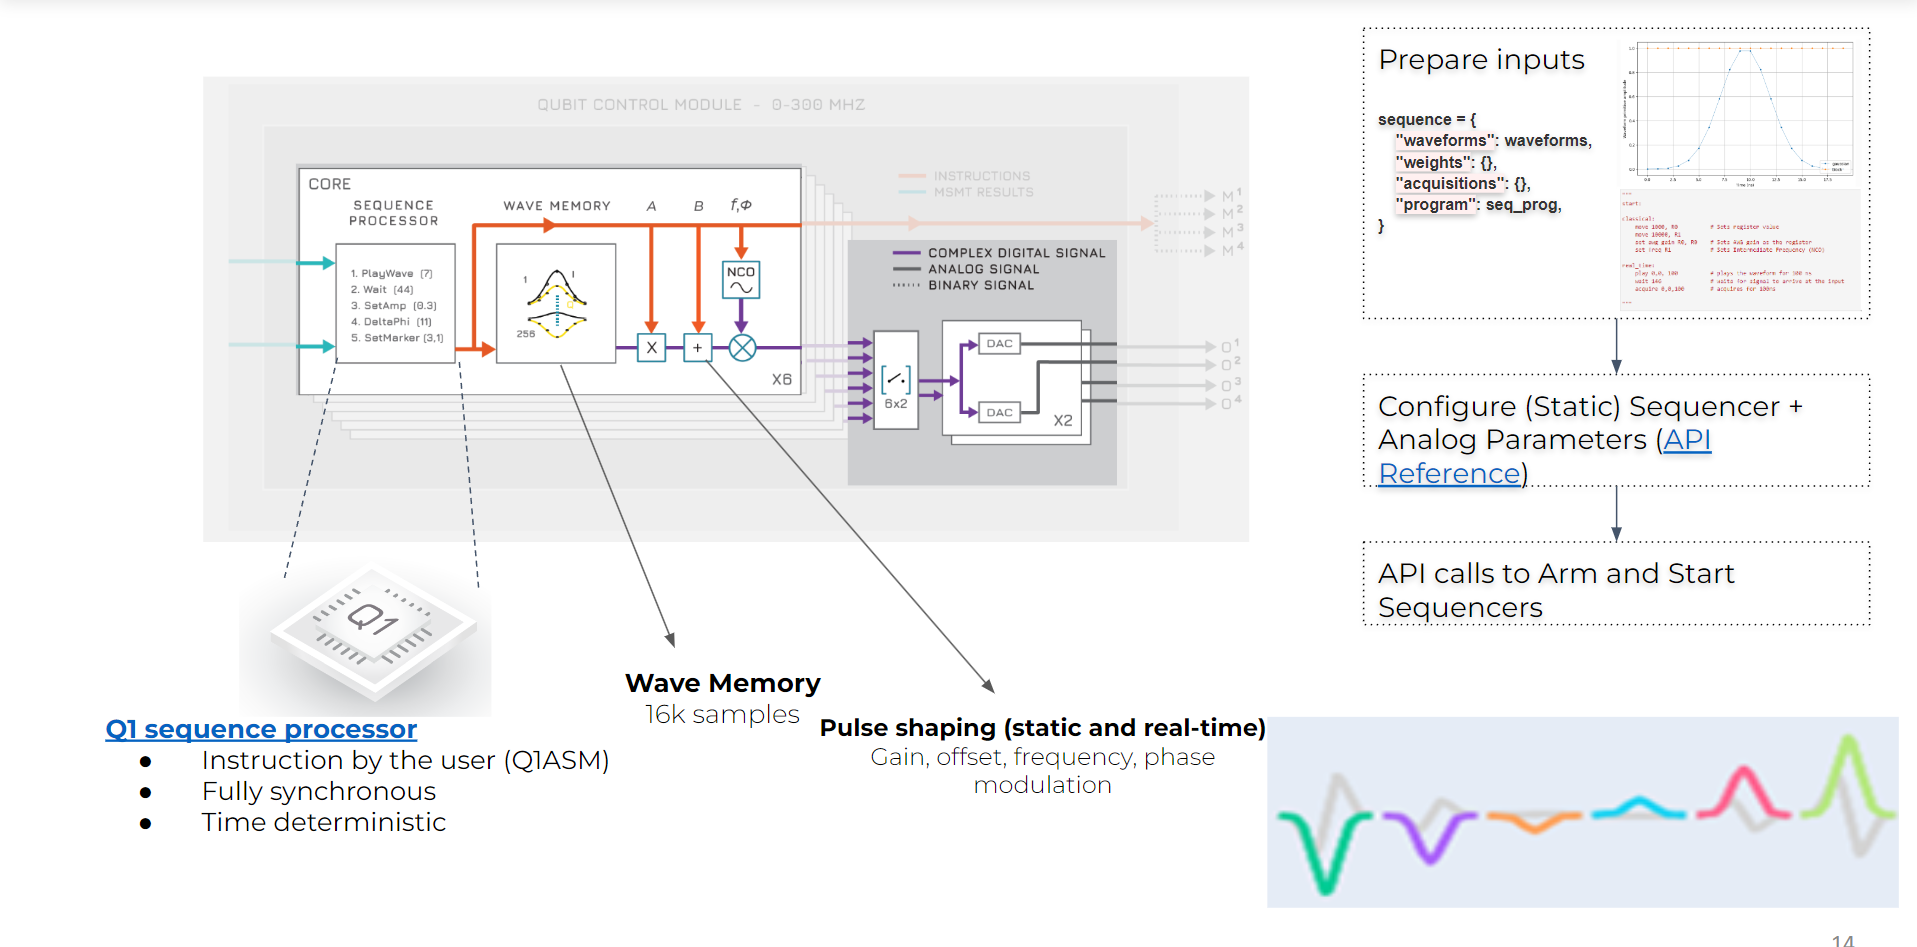

In [20]:
# Set DC offset statically.
control_module.sequencer0.offset_awg_path0(0)
control_module.sequencer0.offset_awg_path1(0)
control_module.sequencer0.mod_en_awg(True)
control_module.sequencer0.nco_freq(50e6)


# Upload the sequence dictionary to our sequencer.
control_module.sequencer0.sequence(sequence)


# Map sequencers to specific outputs (but first disable all sequencer connections).
control_module.disconnect_outputs()
# control_module.sequencer0.connect_out0("I")
# control_module.sequencer0.connect_out1("Q")

control_module.sequencer0.connect_sequencer("out0_1")

In [21]:
# Arm and start the sequencer.
control_module.arm_sequencer(0)

In [22]:
control_module.start_sequencer()

# Print status of the sequencer.
print(control_module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


The NCO
--------------------
The numerically controlled oscillator or NCO can be used to modulate your waveform.

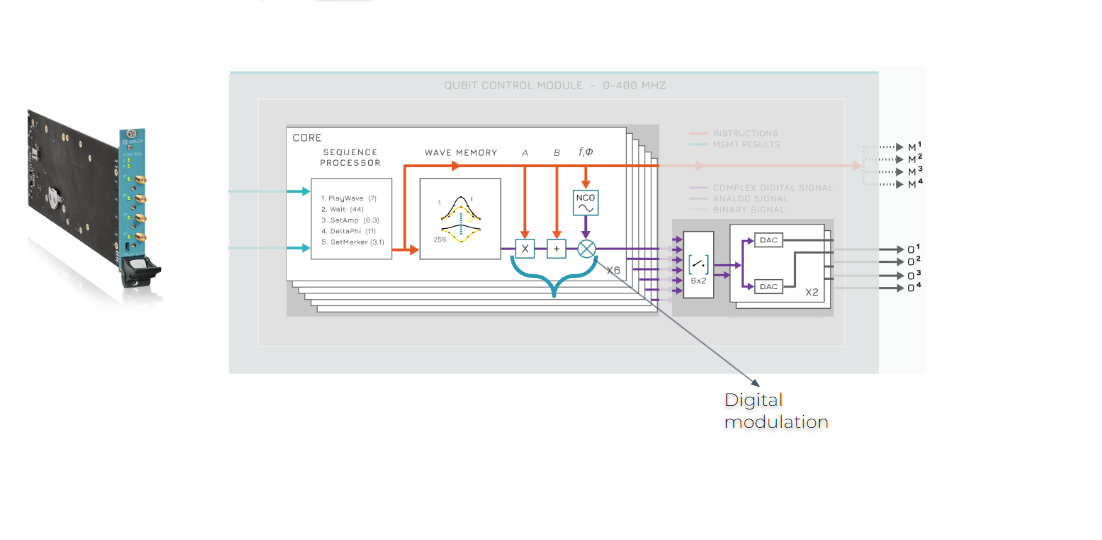

In [25]:
NCO_seq_prog = f"""
       set_mrk 15
       reset_ph  
       set_awg_offs 32767,0     #Set an amplitude of 1 V to path 0.
       set_ph       125000000   #Set the phase to 45 degrees.  
       set_freq     {int(50e6*4)}
       upd_param  1000      #Outputting the values of the waveform and wait a 1000 ns.

       stop                 #Stop the sequence after the last iteration.
"""

In [26]:
nco_sequence = {
    "waveforms": {},
    "weights": {},
    "acquisitions": {},
    "program": NCO_seq_prog,
}

In [27]:
# Set DC offset statically for path 0 and path 1.
control_module.sequencer0.mod_en_awg(True)


control_module.sequencer0.sequence(nco_sequence)

# Map sequencers to specific outputs (but first disable all sequencer connections).
control_module.disconnect_outputs()
control_module.sequencer0.connect_sequencer("out0_1")
# control_module.sequencer0.connect_out0("I")
# control_module.sequencer0.connect_out1("Q")

In [28]:
# Arm and start the sequencer.
control_module.arm_sequencer(0)
control_module.start_sequencer()
# Print status of the sequencer.
print(control_module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


Acquisitions
--------------------

With a readout module such as the QRM/QRM-RF we can acquire data from the output of the readout module due to the high speed analog to digital capability of the readout modules.

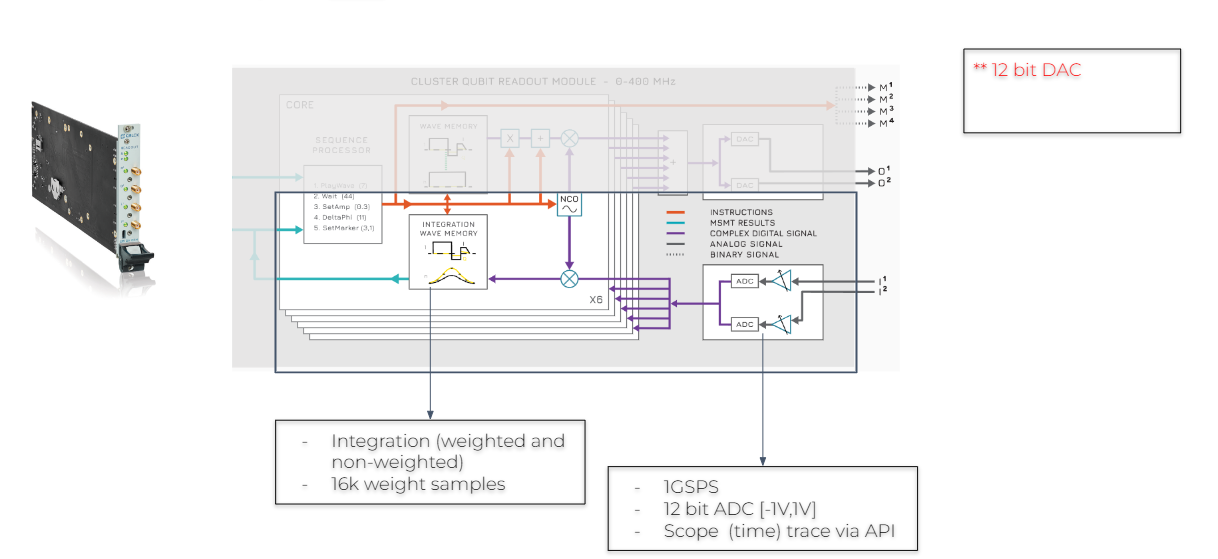

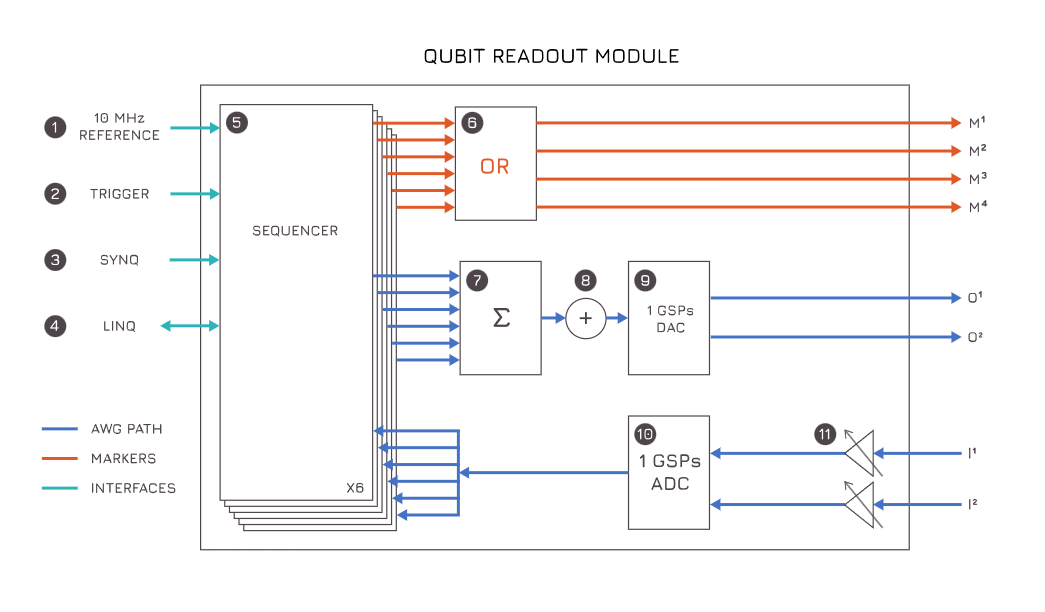

In [29]:
cluster.reset()

In [30]:
waveforms = {
    "gaussian": {
        "data": scipy.signal.windows.gaussian(
            waveform_length, std=0.12 * waveform_length
        ).tolist(),
        "index": 0,
    },
    "sine": {
        "data": [
            math.sin((2 * math.pi / waveform_length) * i)
            for i in range(0, waveform_length)
        ],
        "index": 1,
    },
    "block": {"data": [1.0 for _ in range(0, waveform_length)], "index": 2},
}

In [31]:
#Create a number of different acquisition types.
acquisitions = {
    "non_weighed": {"num_bins": 10, "index": 0},
    "weighed": {"num_bins": 10, "index": 1},
    "large": {"num_bins": 131072, "index": 2},
    "avg": {"num_bins": 10, "index": 3},
    "single": {"num_bins": 1, "index": 4},
}

In [32]:
# Sequence program.
acq_seq_prog = """
set_mrk 15
play    0,0,4     #Play waveforms and wait 4ns. Parameters: waveform index (from dict) on path 0, waveform index (from dict) on path 1, wait (in ns)
acquire 4,0,4     #Acquire waveforms and wait remaining duration of 16380 ns. Parameters: acquisition index (from dict), data bin, Duration of acq (in ns)
stop              #Stop.
"""
# Add sequence to single dictionary and write to JSON file.
acq_sequence = {
    "waveforms": waveforms,
    "weights": {},
    "acquisitions": acquisitions,
    "program": acq_seq_prog,
}
with open("acq_sequence.json", "w", encoding="utf-8") as file:
    json.dump(acq_sequence, file, indent=4)
    file.close()

# Upload sequence
readout_module.sequencer0.sequence("acq_sequence.json")

In [33]:
# Configure the sequencer to trigger the scope acquisition.
readout_module.scope_acq_sequencer_select(0)
readout_module.scope_acq_trigger_mode_path0("sequencer")
readout_module.scope_acq_trigger_mode_path1("sequencer")

# Map sequencer to specific outputs (but first disable all sequencer connections)
readout_module.disconnect_outputs()
readout_module.disconnect_inputs()

if readout_module.is_rf_type:
    readout_module.sequencer0.connect_sequencer("io0")
else:
    readout_module.sequencer0.connect_sequencer("io0_1")

In [34]:
if readout_module.is_rf_type:
    readout_module.out0_in0_lo_freq(4e9)
    readout_module.out0_in0_lo_en(True)
    readout_module.sequencer0.mod_en_awg(True)
    readout_module.sequencer0.nco_freq(100e6)

In [35]:
# Arm and start sequencer.
readout_module.sequencer0.delete_acquisition_data(all=True)
readout_module.arm_sequencer(0)
readout_module.start_sequencer()

# Print status of the sequencer.
print(readout_module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: ACQ_SCOPE_DONE_PATH_0, ACQ_SCOPE_DONE_PATH_1, ACQ_BINNING_DONE, Warning Flags: NONE, Error Flags: NONE, Log: []


In [36]:
# Wait for the acquisition to finish with a timeout period of one minute.
readout_module.get_acquisition_status(0, 1)

# Move acquisition data from temporary memory to acquisition list.
readout_module.store_scope_acquisition(0, "single")

# Get acquisition list from instrument.
single_acq = readout_module.get_acquisitions(0)

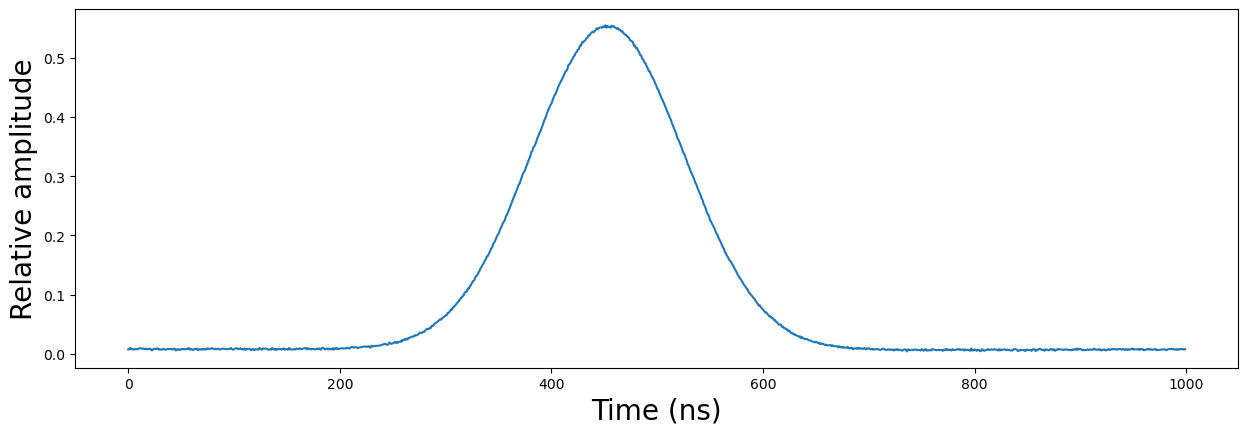

In [37]:
# Plot acquired signal on both inputs.
fig, ax = plt.subplots(1, 1, figsize=(15, 15 / 2 / 1.61))
ax.plot(single_acq["single"]["acquisition"]["scope"]["path0"]["data"][0:1000])
#ax.plot(single_acq["single"]["acquisition"]["scope"]["path1"]["data"][130:1000])
ax.set_xlabel("Time (ns)", fontsize=20)
ax.set_ylabel("Relative amplitude", fontsize=20)
plt.show()

Binned acquisitions
--------------------
We can also use bins which stores the integration and discretization results of the acquired data. The binned data is also possible to average in the bins. To show that this actually happens during the binning process, we compare the data stored in the bins with an actual integration of the acquisition data.

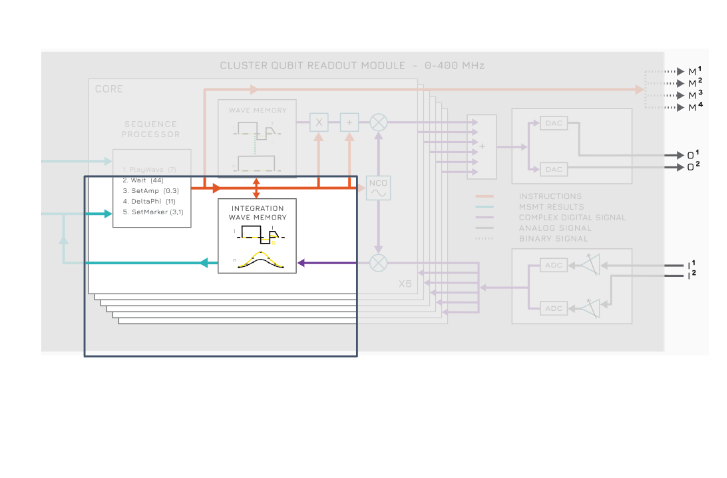

## GOAL : Integrate a Sine Wave for Different Integration Times  

### First Step: Q1ASM for a Sine output and Triggering Acquisition  

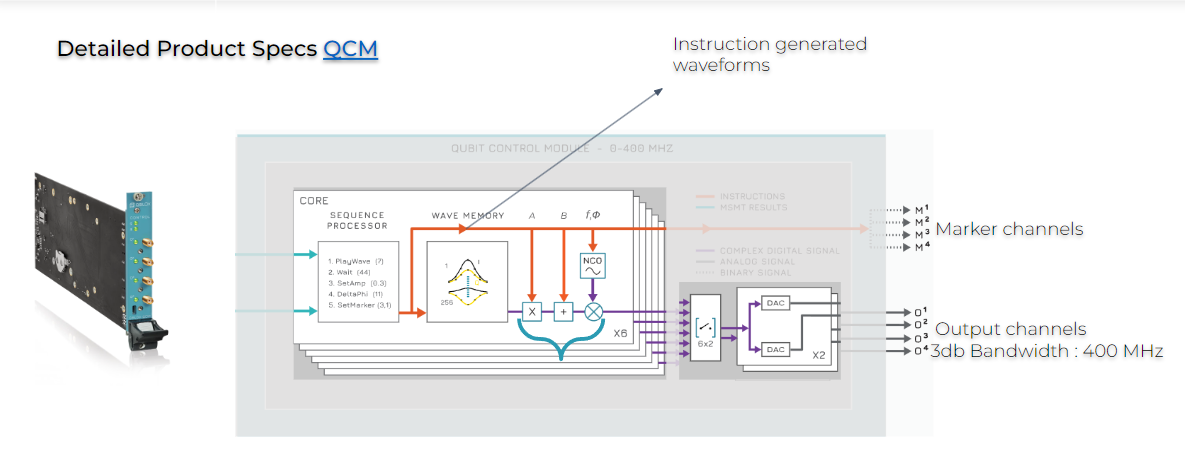

In [38]:
#Create a number of different acquisition types.
acquisitions = {
    "non_weighed": {"num_bins": 10, "index": 0},
    "weighed": {"num_bins": 10, "index": 1},
    "large": {"num_bins": 131072, "index": 2},
    "avg": {"num_bins": 10, "index": 3},
    "single": {"num_bins": 1, "index": 4},
}

**NOTE : The arguments of the `acquire` command**  

In [39]:
# Sequence program for the binned acquisition over a single bin.
bin_seq_prog = """
      set_awg_offs 10000,0   #Set the offset to 0.3 V.
      upd_param 100
      move 100, R0
      
avg_loop:
      set_mrk 15
      reset_ph
      upd_param 200
      acquire 4,0,1000  #Acquire and store the values in a single bin.
      loop R0,@avg_loop
      stop                #Stop.
"""

In [40]:
readout_module.sequencer0.nco_freq(50e6)
readout_module.sequencer0.mod_en_awg(True)

In [41]:
# Sequence for the binned acquisition program.
bin_sequence = {
    "waveforms": waveforms,
    "weights": {},
    "acquisitions": acquisitions,
    "program": bin_seq_prog,
}

### Second Step : Set the Acquisition For Integrating

In [42]:
# Upload sequence
readout_module.sequencer0.sequence(bin_sequence)

# Configure scope mode
readout_module.scope_acq_sequencer_select(0)
readout_module.scope_acq_trigger_mode_path0("sequencer")
readout_module.scope_acq_trigger_mode_path1("sequencer")

# Configure the sequencer
readout_module.sequencer0.demod_en_acq(False)

### Sweep the Integration Time and Acquire the Results

Text(0.5, 1.0, 'Scope Acquisition of All Runs')

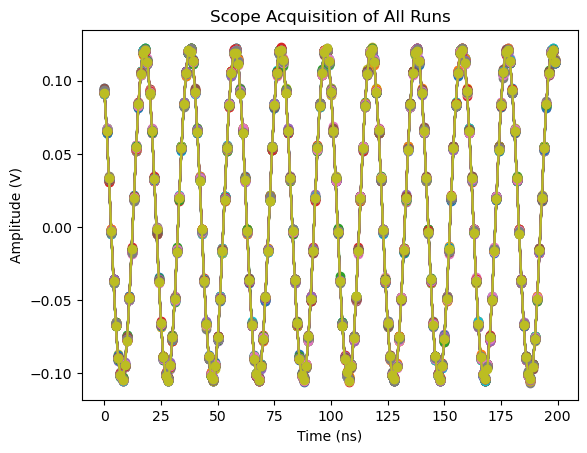

In [43]:
integration_range = np.arange(4,200,4)

sample_data_0 = []
sample_data_1 = []
for val in integration_range:
    # Update the integration length.
    readout_module.sequencer0.integration_length_acq(val)

    # Clear acquisitions
    readout_module.sequencer0.delete_acquisition_data(all=True)

    readout_module.arm_sequencer(0)
    readout_module.start_sequencer()

    # Wait for the sequencer to stop with a timeout period of one minute.
    readout_module.get_acquisition_status(0, timeout=1)

    # Move acquisition data from temporary memory to acquisition list.
    readout_module.store_scope_acquisition(0, "single")

    # Get acquisition list from instrument.
    data = readout_module.get_acquisitions(0)["single"]

    # Store the acquisition data.
    sample_data_0.append(np.array(data["acquisition"]["bins"]["integration"]["path0"][0]))
    sample_data_1.append(np.array(data["acquisition"]["bins"]["integration"]["path1"][0]))
    plt.plot(data["acquisition"]["scope"]["path0"]["data"][0:200],'-o')

plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (V)")
plt.title("Scope Acquisition of All Runs")

**It is time to plot the integrated results!**

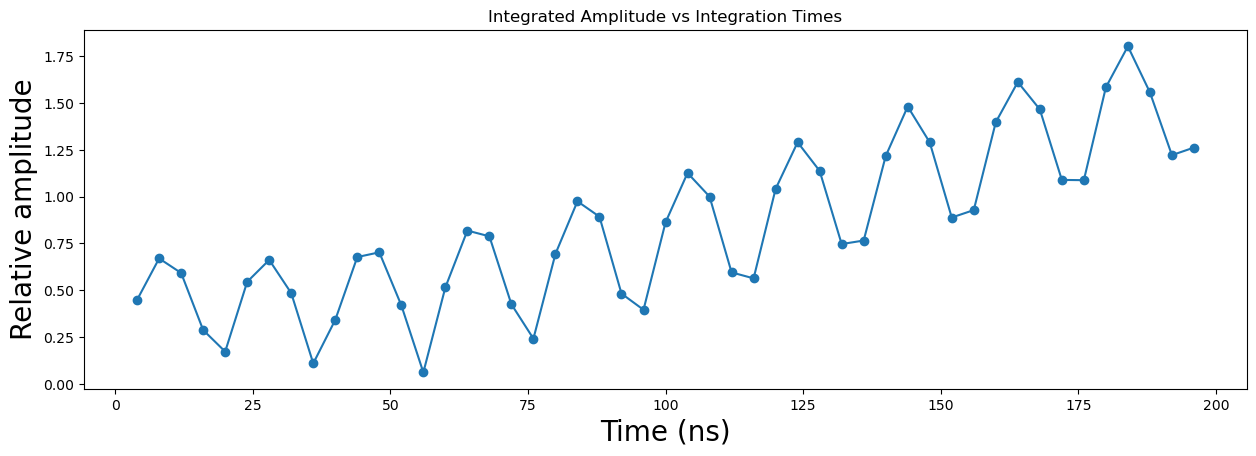

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15 / 2 / 1.61))
ax.plot(integration_range,np.asarray(np.sqrt(np.array(sample_data_0)**2 + np.array(sample_data_1)**2)),'-o')
# ax.plot(np.asarray(np.array(sample_data_0)), '-o')
# ax.plot(np.asarray(np.array(sample_data_1)), '-o')
ax.set_xlabel("Time (ns)", fontsize=20)
ax.set_ylabel("Relative amplitude", fontsize=20)
plt.title("Integrated Amplitude vs Integration Times")
plt.show()

Extended example of acquisition with Q1ASM
--------------------

In [45]:
# Sequence program.
adv_seq_prog = """
        move 5, R0                 #Loop over 10 steps.
        move 0, R1                  #Start offset
        nop
        acquire 4, 0, 4
        
        set_awg_offs R1, R1         #Set amplitude of the signal to 1V.
        upd_param 4                 #Execute the signal for 4 ns.
        
loop:
        add R1, 1000, R1     #Update the amplitude for next run. 
        nop
        set_awg_offs R1, R1         #Increase the amplitude with the offset = start_ampl + ampl_incr.
        upd_param 100               #Execute the wave for 100ns
        loop R0, @loop              #Loop over the number of steps. 

        set_awg_offs 0, 0           #Reset the wave signal. 
        upd_param 4                 #Show the reset signal. 
        stop
"""

# Add sequence to single dictionary and write to JSON file.
adv_sequence = {
    "waveforms": waveforms,
    "weights": {},
    "acquisitions": acquisitions,
    "program": adv_seq_prog,
}
with open("adv_sequence.json", "w", encoding="utf-8") as file:
    json.dump(adv_sequence, file, indent=4)
    file.close()

# Upload sequence
readout_module.sequencer0.sequence("adv_sequence.json")

In [46]:
# Upload sequence.
#readout_module.sequencer0.sequence("acq_sequence.json")

readout_module.disconnect_outputs()
readout_module.disconnect_inputs()

# Configure channel map
readout_module.sequencer0.connect_sequencer("io0_1")

readout_module.sequencer0.marker_ovr_en(True)
readout_module.sequencer0.marker_ovr_value(15)  # Enables output on QRM-RF

# Configure scope mode
readout_module.scope_acq_sequencer_select(0)

readout_module.scope_acq_trigger_mode_path0("sequencer")
readout_module.scope_acq_trigger_mode_path1("sequencer")

# Configure the sequencer
readout_module.sequencer0.mod_en_awg(True)
readout_module.sequencer0.demod_en_acq(False)
readout_module.sequencer0.nco_freq(50e6)
readout_module.sequencer0.sync_en(True)

# NCO delay compensation
readout_module.sequencer0.nco_prop_delay_comp_en(True)

readout_module.delete_acquisition_data(0,all=True)

In [47]:
# Arm and start sequencer.
readout_module.arm_sequencer(0)
readout_module.start_sequencer()

# Print status of the sequencer.
print(readout_module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: ACQ_SCOPE_DONE_PATH_0, ACQ_SCOPE_DONE_PATH_1, ACQ_BINNING_DONE, Warning Flags: NONE, Error Flags: NONE, Log: []


In [48]:
# Wait for the acquisition to finish with a timeout period of one minute.
readout_module.get_acquisition_status(0, 1)

# Move acquisition data from temporary memory to acquisition list.
readout_module.store_scope_acquisition(0, "single")

# Get acquisition list from instrument.
single_acq = readout_module.get_acquisitions(0)["single"]

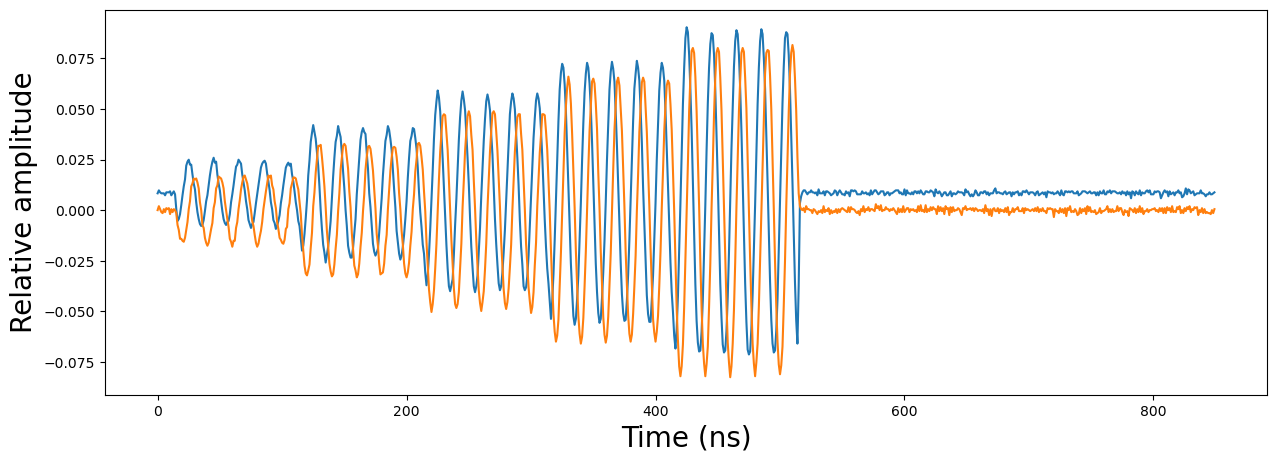

In [49]:
# Plot acquired signal on one of the inputs.
fig, ax = plt.subplots(1, 1, figsize=(15, 15 / 2 / 1.5))
ax.plot(single_acq["acquisition"]["scope"]["path0"]["data"][150:1000])
ax.plot(single_acq["acquisition"]["scope"]["path1"]["data"][150:1000])
ax.set_xlabel("Time (ns)", fontsize=20)
ax.set_ylabel("Relative amplitude", fontsize=20)
plt.show()

Stop
----

Finally, let's stop the sequencers if they haven't already and close the instrument connection. One can also display a detailed snapshot containing the instrument parameters before
closing the connection by uncommenting the corresponding lines.

In [51]:
# Stop sequencer.
readout_module.stop_sequencer()

# Print status of sequencer.
print(readout_module.get_sequencer_status(0))

# Reset the cluster
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE
